# Analysis of linear probing

In this notebook we would analyse how both ViT models handle linear probing on emotion. Make sure to execute those 2 commends before running the notebook:

In [1]:
import os
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

# !make run_feature_extraction_trpakov
# !make run_feature_extraction_vitbase
# !make run_linear_probing_trpakov
# !make run_linear_probing_vitbase


In [2]:
!pwd
!ls data/analysis/

/home/nikodem/Workspace/2-sem-mgr/ViT-Empathy
OLD_vitbase_cls_seed42_linear_probe_results.csv
vitbase_cls_seed42
vitbase_cls_seed42_linear_probe_results.csv
vitface_cls_seed42
vitface_cls_seed42_linear_probe_results.csv


In [3]:
import pandas as pd

base_linear_probing_res = pd.read_csv('./data/analysis/vitbase_cls_seed42_linear_probe_results.csv')
face_linear_probing_res = pd.read_csv('./data/analysis/vitface_cls_seed42_linear_probe_results.csv')


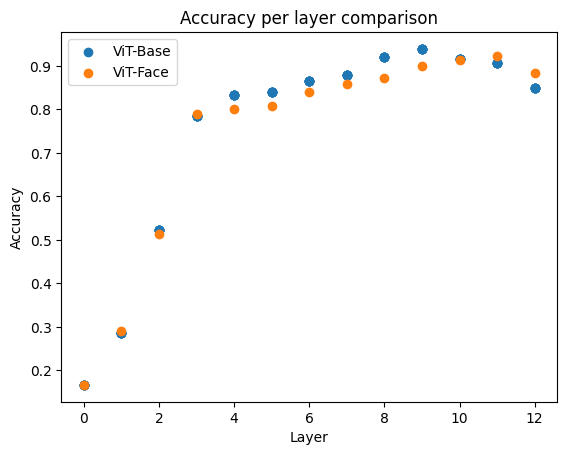

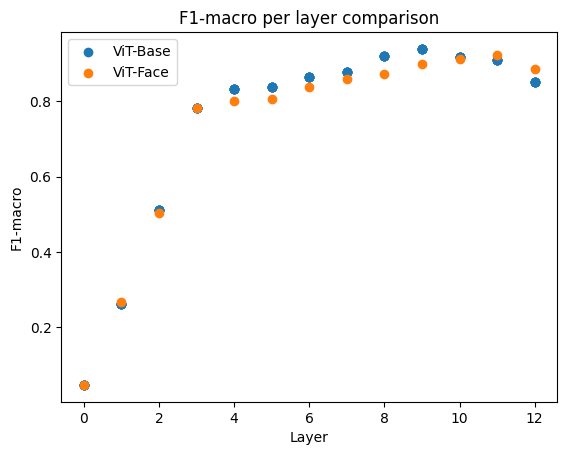

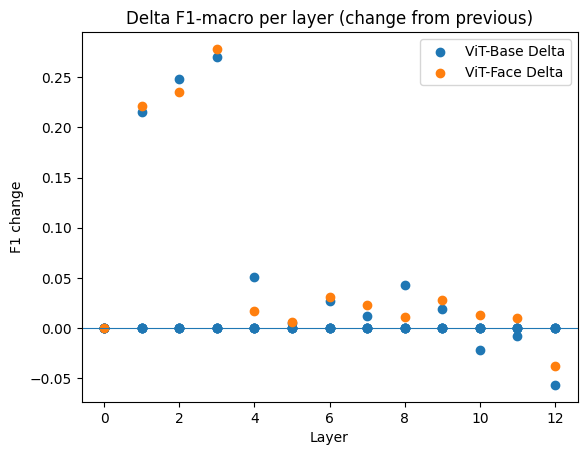

In [4]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def rebuild_cm(row):
    flat = ast.literal_eval(row["confusion"])
    shape = ast.literal_eval(row["confusion_shape"])
    return np.array(flat).reshape(shape)

for df in [base_linear_probing_res, face_linear_probing_res]:
    f1s = []
    for _, row in df.iterrows():
        cm = rebuild_cm(row)
        y_true = []
        y_pred = []
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                y_true += [i] * cm[i, j]
                y_pred += [j] * cm[i, j]
        f1s.append(f1_score(y_true, y_pred, average="macro"))
    df["f1"] = f1s

def compute_delta(series):
    return [series[i] - series[i-1] for i in range(len(series))]

base_linear_probing_res["f1_delta"] = [0] + compute_delta(base_linear_probing_res["f1"].values)[1:]
face_linear_probing_res["f1_delta"] = [0] + compute_delta(face_linear_probing_res["f1"].values)[1:]

base_linear_probing_res["accuracy_delta"] = [0] + compute_delta(base_linear_probing_res["accuracy"].values)[1:]
face_linear_probing_res["accuracy_delta"] = [0] + compute_delta(face_linear_probing_res["accuracy"].values)[1:]

plt.figure()
plt.scatter(base_linear_probing_res["layer"], base_linear_probing_res["accuracy"])
plt.scatter(face_linear_probing_res["layer"], face_linear_probing_res["accuracy"])
plt.title("Accuracy per layer comparison")
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.legend(["ViT-Base", "ViT-Face"])
plt.show()

plt.figure()
plt.scatter(base_linear_probing_res["layer"], base_linear_probing_res["f1"])
plt.scatter(face_linear_probing_res["layer"], face_linear_probing_res["f1"])
plt.title("F1-macro per layer comparison")
plt.xlabel("Layer")
plt.ylabel("F1-macro")
plt.legend(["ViT-Base", "ViT-Face"])
plt.show()

plt.figure()
plt.scatter(base_linear_probing_res["layer"], base_linear_probing_res["f1_delta"])
plt.scatter(face_linear_probing_res["layer"], face_linear_probing_res["f1_delta"])
plt.title("Delta F1-macro per layer (change from previous)")
plt.xlabel("Layer")
plt.ylabel("F1 change")
plt.legend(["ViT-Base Delta", "ViT-Face Delta"])
plt.axhline(0, linewidth=0.8)
plt.show()


In [5]:
vitbase = base_linear_probing_res.copy()

layers = vitbase["layer"].values 
f1 = vitbase["f1"].round(4).values
delta = vitbase["f1_delta"].round(4).values

cols = [str(l) for l in layers]
table = pd.DataFrame([f1, delta], columns=cols, index=["f1", "delta_f1"])

print("\nViT-Base linear probing results:")
print(table)



ViT-Base linear probing results:
               0       0       0       0       0       0       1       1  \
f1        0.0476  0.0476  0.0476  0.0476  0.0476  0.0476  0.2627  0.2627   
delta_f1  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.2151  0.0000   

               1       1  ...      11      11      11      11      12      12  \
f1        0.2627  0.2627  ...  0.9088  0.9088  0.9088  0.9088  0.8521  0.8521   
delta_f1  0.0000  0.0000  ...  0.0000  0.0000  0.0000  0.0000 -0.0567  0.0000   

              12      12      12      12  
f1        0.8521  0.8521  0.8521  0.8521  
delta_f1  0.0000  0.0000  0.0000  0.0000  

[2 rows x 78 columns]


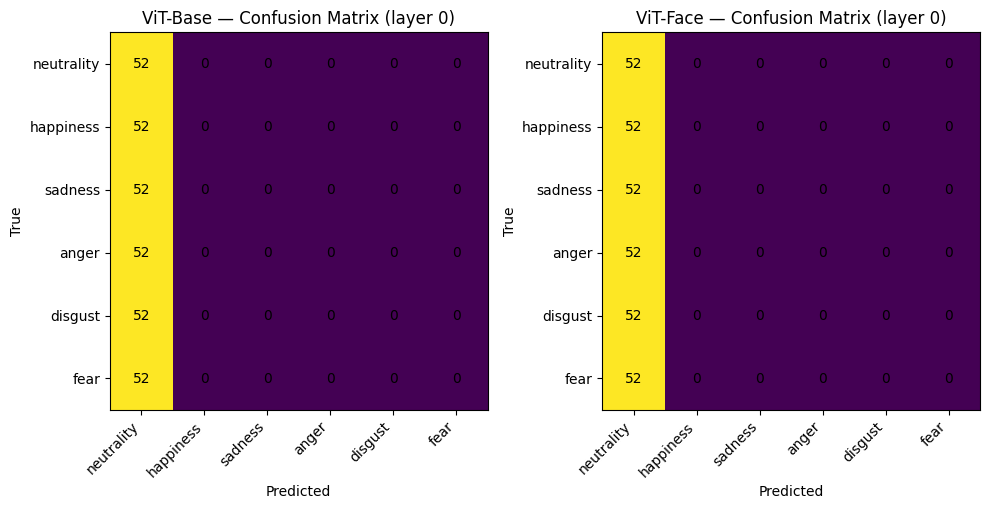

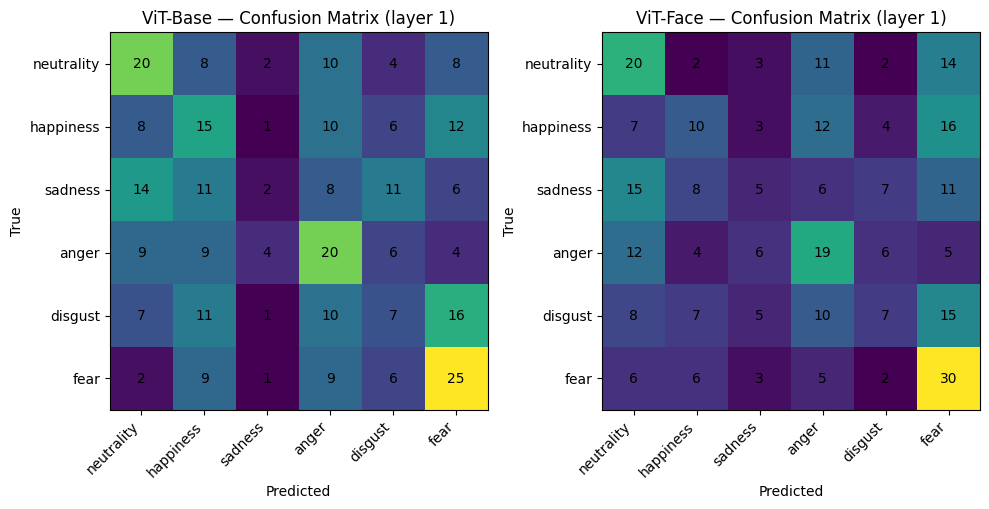

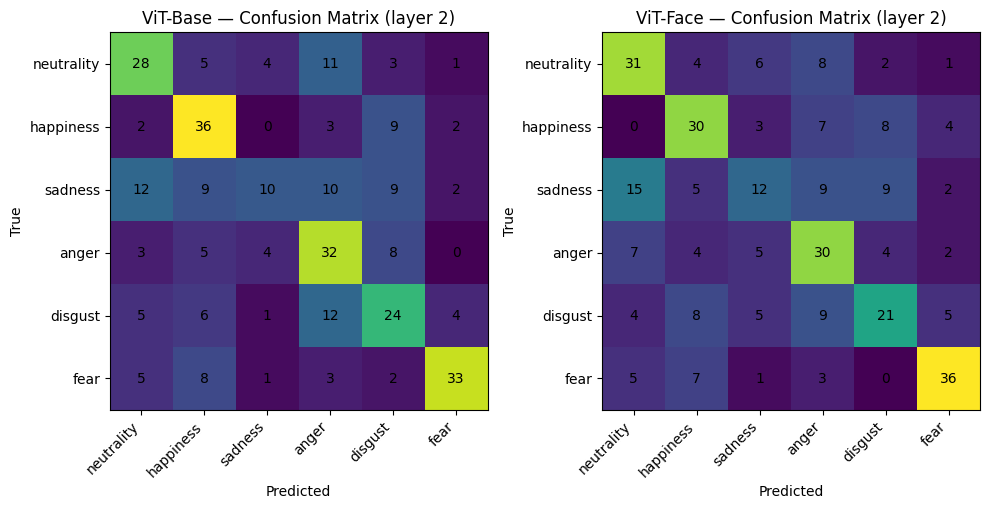

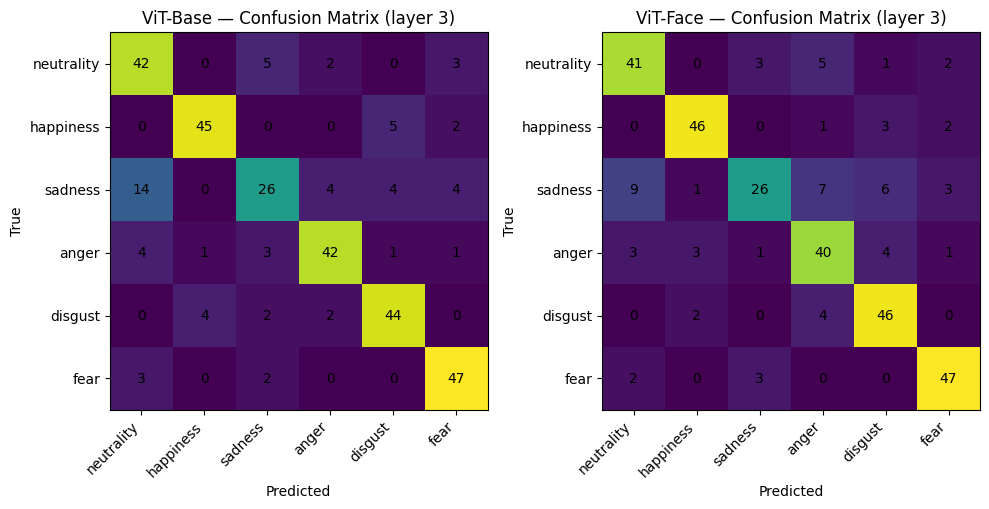

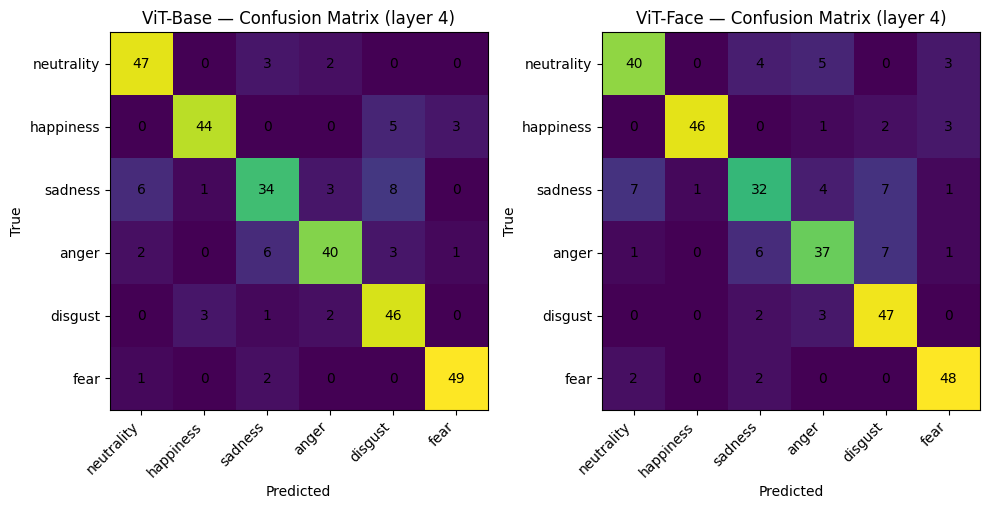

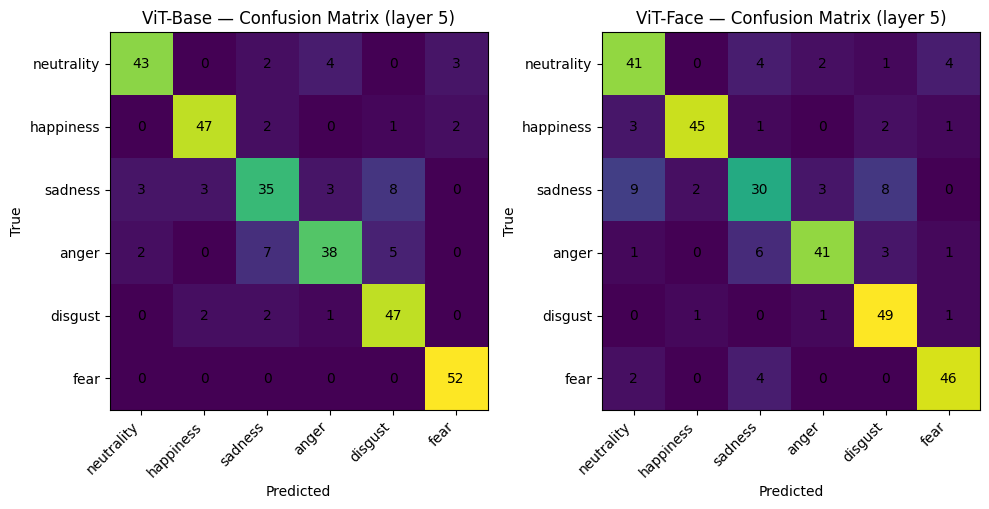

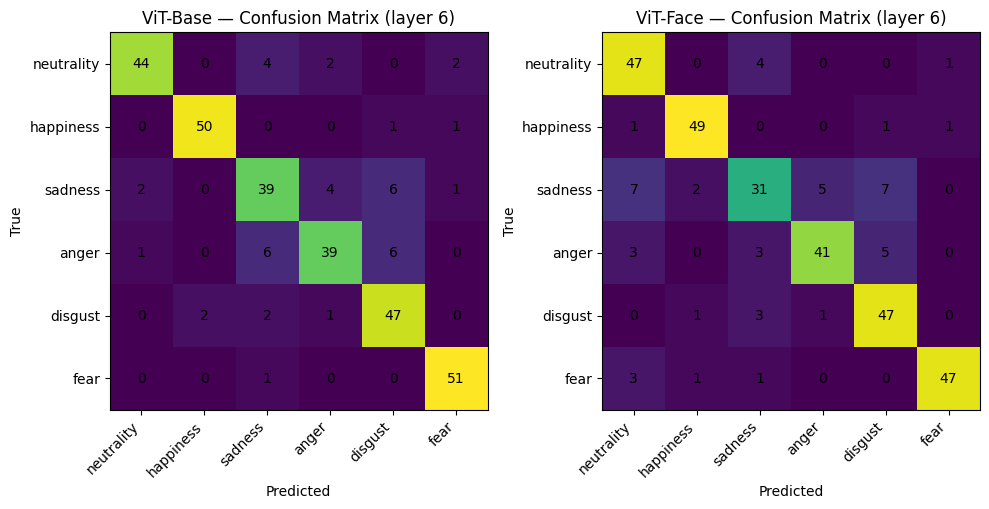

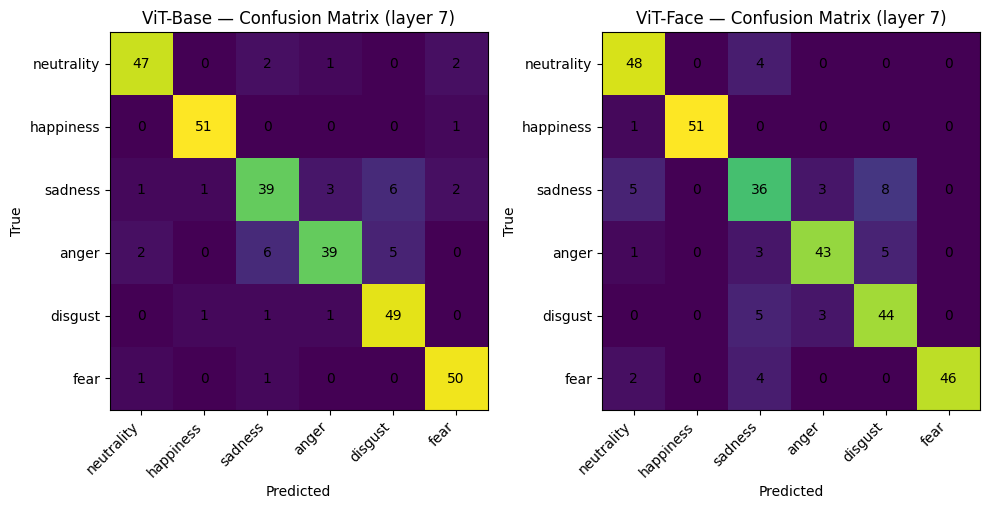

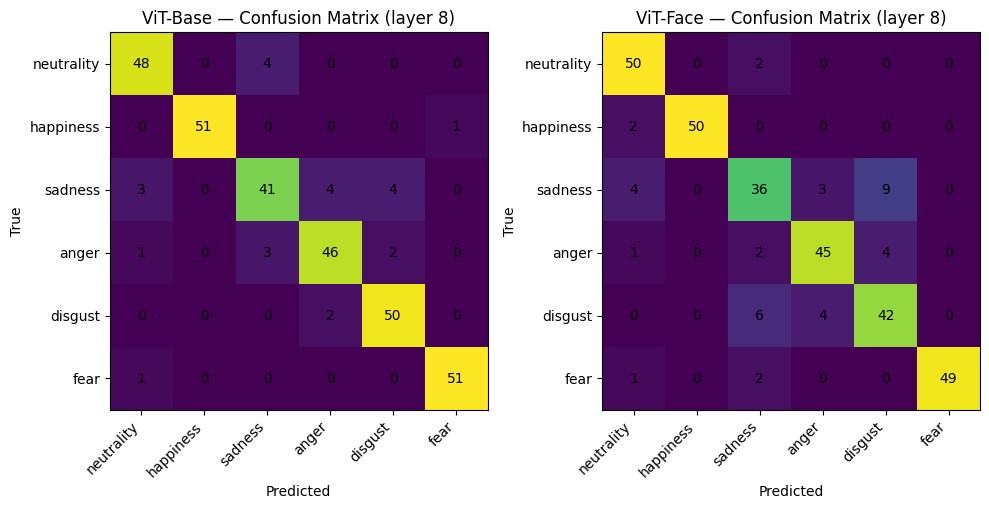

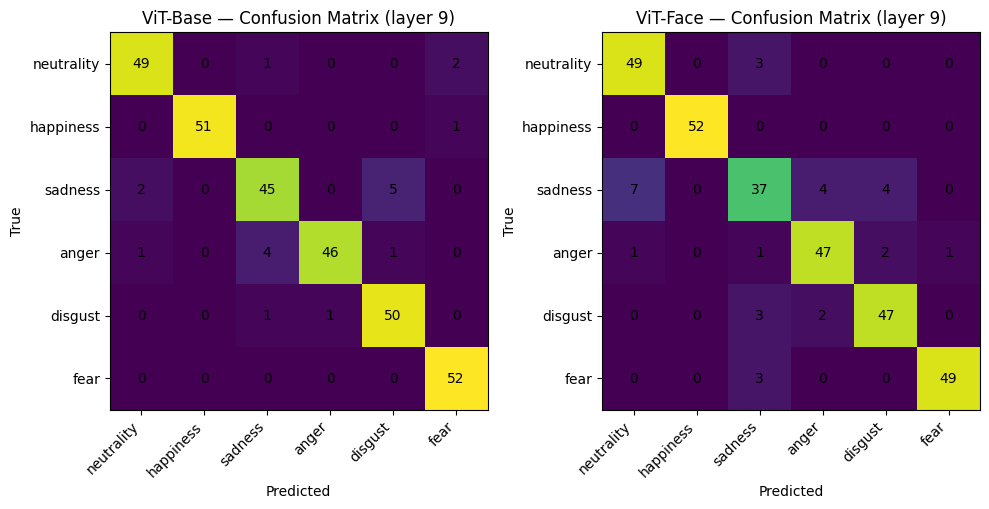

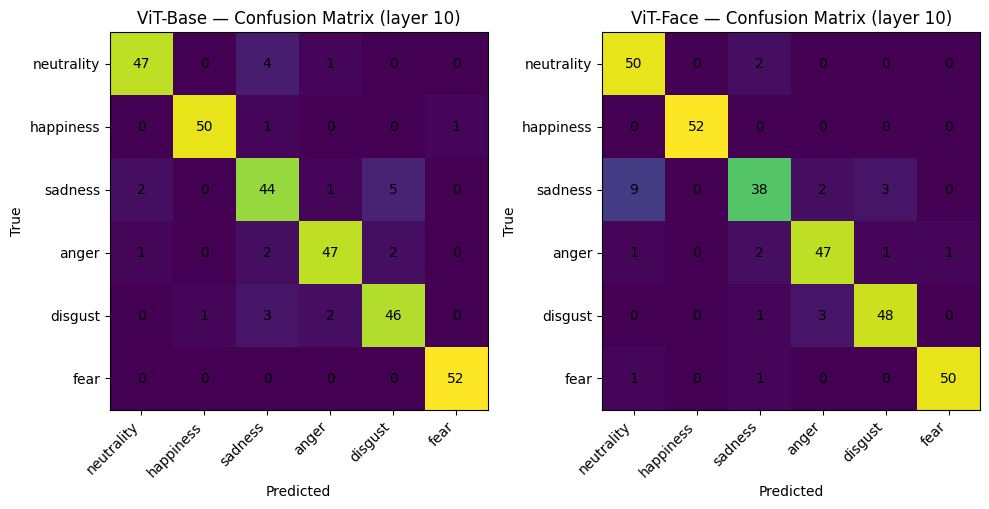

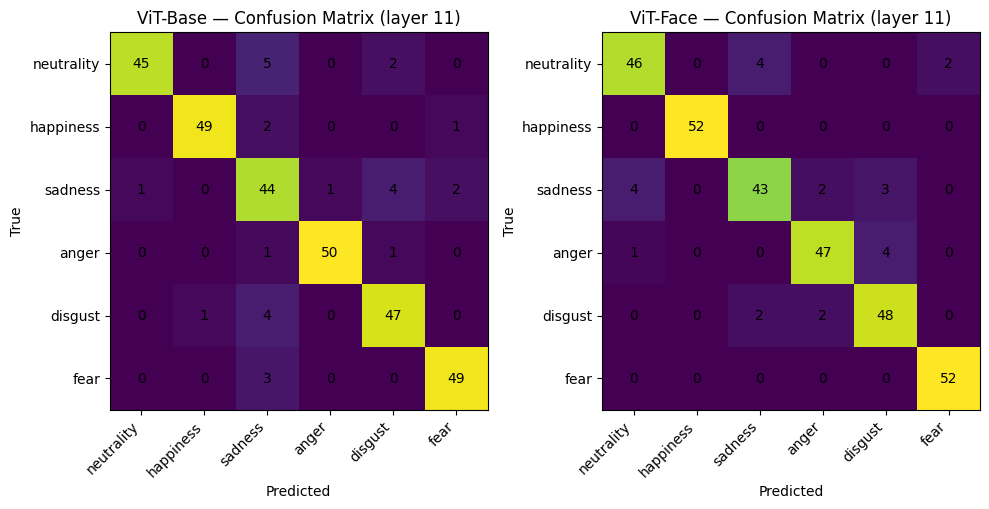

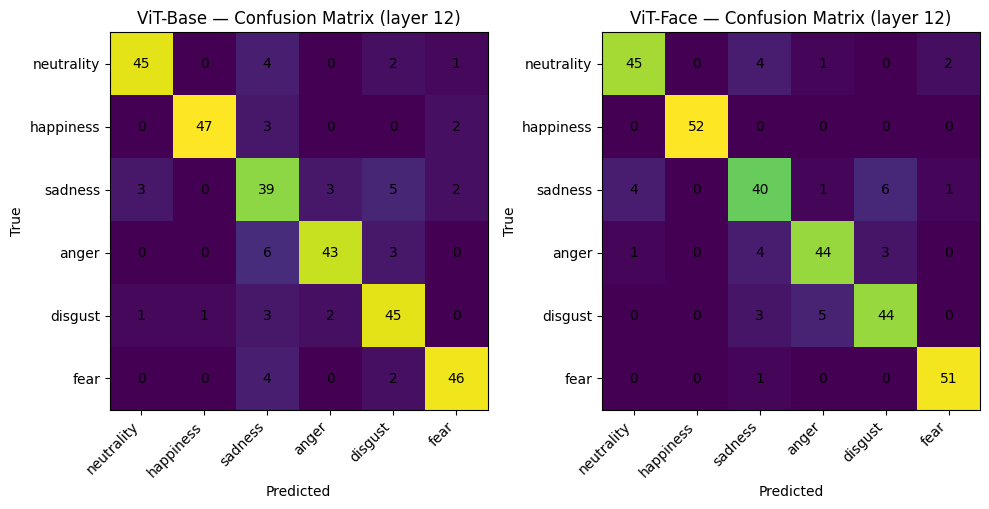

In [7]:
emotion_map = ["neutrality", "happiness", "sadness", "anger", "disgust", "fear"]

num_layers = base_linear_probing_res.shape[0]

for i in range(num_layers):
    cm_b = rebuild_cm(base_linear_probing_res.iloc[i])
    cm_f = rebuild_cm(face_linear_probing_res.iloc[i])

    fig, axes = plt.subplots(1, 2, figsize=(10, 16))

    for ax, cm, title in [
        (axes[0], cm_b, "ViT-Base"),
        (axes[1], cm_f, "ViT-Face")
    ]:
        ax.imshow(cm)
        ax.set_title(f"{title} — Confusion Matrix (layer {i})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(6))
        ax.set_yticks(range(6))
        ax.set_xticklabels(emotion_map, rotation=45, ha="right")  
        ax.set_xticklabels(emotion_map)
        ax.set_yticklabels(emotion_map)

        for r in range(cm.shape[0]):
            for c in range(cm.shape[1]):
                ax.text(
                    c, r, str(cm[r, c]),
                    ha="center", va="center"
                )

    plt.tight_layout()
    plt.show()


In [21]:

def neutral_recall(cm):
    return cm[0, 0] / (cm[0].sum() + 1e-6)

base_linear_probing_res["neutral_recall"] = base_linear_probing_res.apply(
    lambda row: neutral_recall(rebuild_cm(row)), axis=1
)
face_linear_probing_res["neutral_recall"] = face_linear_probing_res.apply(
    lambda row: neutral_recall(rebuild_cm(row)), axis=1
)

def compute_delta_list(values):
    return [0] + [values[i] - values[i-1] for i in range(1, len(values))]

base_linear_probing_res["neutral_recall_delta"] = compute_delta_list(
    base_linear_probing_res["neutral_recall"].values
)
face_linear_probing_res["neutral_recall_delta"] = compute_delta_list(
    face_linear_probing_res["neutral_recall"].values
)

vitb = base_linear_probing_res

print("ViT-Base neutral probing summary:\n")
header = "Layer | " + " | ".join(str(int(x)) for x in vitb["layer"].values)
print(header)
print("f1     | " + " | ".join(f"{x:.4f}" for x in vitb["f1"].values))
print("Delta f1   | " + " | ".join(f"{x:.4f}" for x in vitb["f1_delta"].values))
print("acc    | " + " | ".join(f"{x:.4f}" for x in vitb["accuracy"].values))
print("Delta acc  | " + " | ".join(f"{x:.4f}" for x in vitb["accuracy_delta"].values))
print("neut R | " + " | ".join(f"{x:.4f}" for x in vitb["neutral_recall"].values))
print("Delta neut | " + " | ".join(f"{x:.4f}" for x in vitb["neutral_recall_delta"].values))


ViT-Base neutral probing summary:

Layer | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 2 | 2 | 2 | 2 | 2 | 2 | 3 | 3 | 3 | 3 | 3 | 3 | 4 | 4 | 4 | 4 | 4 | 4 | 5 | 5 | 5 | 5 | 5 | 5 | 6 | 6 | 6 | 6 | 6 | 6 | 7 | 7 | 7 | 7 | 7 | 7 | 8 | 8 | 8 | 8 | 8 | 8 | 9 | 9 | 9 | 9 | 9 | 9 | 10 | 10 | 10 | 10 | 10 | 10 | 11 | 11 | 11 | 11 | 11 | 11 | 12 | 12 | 12 | 12 | 12 | 12
f1     | 0.0476 | 0.0476 | 0.0476 | 0.0476 | 0.0476 | 0.0476 | 0.2627 | 0.2627 | 0.2627 | 0.2627 | 0.2627 | 0.2627 | 0.5112 | 0.5112 | 0.5112 | 0.5112 | 0.5112 | 0.5112 | 0.7814 | 0.7814 | 0.7814 | 0.7814 | 0.7814 | 0.7814 | 0.8321 | 0.8321 | 0.8321 | 0.8321 | 0.8321 | 0.8321 | 0.8376 | 0.8376 | 0.8376 | 0.8376 | 0.8376 | 0.8376 | 0.8648 | 0.8648 | 0.8648 | 0.8648 | 0.8648 | 0.8648 | 0.8765 | 0.8765 | 0.8765 | 0.8765 | 0.8765 | 0.8765 | 0.9194 | 0.9194 | 0.9194 | 0.9194 | 0.9194 | 0.9194 | 0.9389 | 0.9389 | 0.9389 | 0.9389 | 0.9389 | 0.9389 | 0.9170 | 0.9170 | 0.9170 | 0.9170 | 0.9170 | 0.9170 | 0.9088 | 0.9088 | 0.9088 |

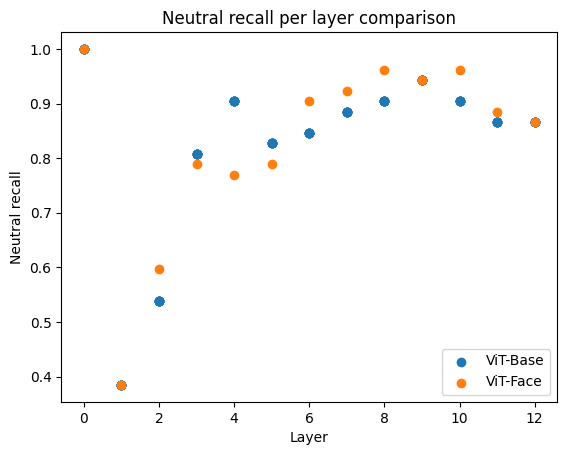

In [22]:
plt.figure()
plt.scatter(base_linear_probing_res["layer"], base_linear_probing_res["neutral_recall"])
plt.scatter(face_linear_probing_res["layer"], face_linear_probing_res["neutral_recall"])
plt.title("Neutral recall per layer comparison")
plt.xlabel("Layer")
plt.ylabel("Neutral recall")
plt.legend(["ViT-Base", "ViT-Face"])
plt.show()

In [23]:
base_linear_probing_res["neutral_recall"]

0     1.000000
1     1.000000
2     1.000000
3     1.000000
4     1.000000
        ...   
73    0.865385
74    0.865385
75    0.865385
76    0.865385
77    0.865385
Name: neutral_recall, Length: 78, dtype: float64

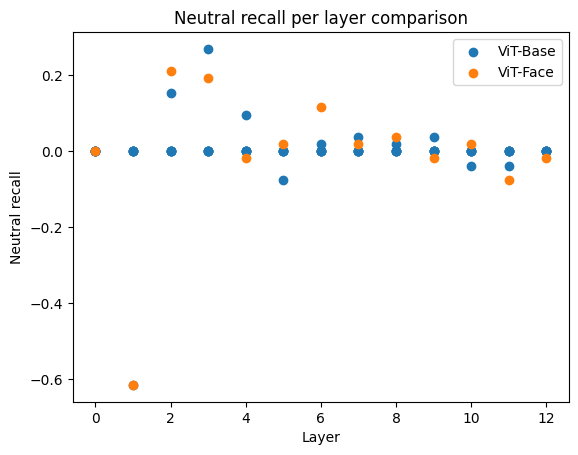

In [24]:
plt.figure()
plt.scatter(base_linear_probing_res["layer"], base_linear_probing_res["neutral_recall_delta"])
plt.scatter(face_linear_probing_res["layer"], face_linear_probing_res["neutral_recall_delta"])
plt.title("Neutral recall per layer comparison")
plt.xlabel("Layer")
plt.ylabel("Neutral recall")
plt.legend(["ViT-Base", "ViT-Face"])
plt.show()

In [26]:
base_linear_probing_res

,layer,emotion,class_index,accuracy,balanced_accuracy,f1,confusion,confusion_shape,num_samples,weights,bias,f1_delta,accuracy_delta,neutral_recall,neutral_recall_delta
0,0,neutrality,0,0.166667,0.166667,0.047619,"[52, 0, 0, 0, 0, 0, 52, 0, 0, 0, 0, 0, 52, 0, ...","(6, 6)",312,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.0,0.0,1.000000,0.0
1,0,happiness,1,0.166667,0.166667,0.047619,"[52, 0, 0, 0, 0, 0, 52, 0, 0, 0, 0, 0, 52, 0, ...","(6, 6)",312,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.0,0.0,1.000000,0.0
2,0,sadness,2,0.166667,0.166667,0.047619,"[52, 0, 0, 0, 0, 0, 52, 0, 0, 0, 0, 0, 52, 0, ...","(6, 6)",312,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.0,0.0,1.000000,0.0
3,0,anger,3,0.166667,0.166667,0.047619,"[52, 0, 0, 0, 0, 0, 52, 0, 0, 0, 0, 0, 52, 0, ...","(6, 6)",312,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.0,0.0,1.000000,0.0
4,0,disgust,4,0.166667,0.166667,0.047619,"[52, 0, 0, 0, 0, 0, 52, 0, 0, 0, 0, 0, 52, 0, ...","(6, 6)",312,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.000000,0.0,0.0,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,12,happiness,1,0.849359,0.849359,0.852114,"[45, 0, 4, 0, 2, 1, 0, 47, 3, 0, 0, 2, 3, 0, 3...","(6, 6)",312,"[0.06405210583759145, -0.0009518069839211174, ...",-0.003848,0.0,0.0,0.865385,0.0
74,12,sadness,2,0.849359,0.849359,0.852114,"[45, 0, 4, 0, 2, 1, 0, 47, 3, 0, 0, 2, 3, 0, 3...","(6, 6)",312,"[0.08190977081707185, 0.06262566671791177, 0.0...",0.004297,0.0,0.0,0.865385,0.0
75,12,anger,3,0.849359,0.849359,0.852114,"[45, 0, 4, 0, 2, 1, 0, 47, 3, 0, 0, 2, 3, 0, 3...","(6, 6)",312,"[-0.05894462431980242, -0.06899073791621703, -...",0.001351,0.0,0.0,0.865385,0.0
76,12,disgust,4,0.849359,0.849359,0.852114,"[45, 0, 4, 0, 2, 1, 0, 47, 3, 0, 0, 2, 3, 0, 3...","(6, 6)",312,"[-0.08158939063380458, -0.1967155990195884, -0...",-0.002306,0.0,0.0,0.865385,0.0


In [6]:
import ast
import numpy as np
import pandas as pd

df = base_linear_probing_res.copy()

neutral_df = df[df["emotion"] == "neutrality"].copy()

neutral_df["weights"] = neutral_df["weights"].apply(ast.literal_eval)

neutral_df["weight_norm"] = neutral_df["weights"].apply(
    lambda w: np.linalg.norm(np.array(w))
)

for _, r in neutral_df.iterrows():
    w = np.array(r.weights)
    print(f"\nLayer {int(r.layer)} neutral weight vector (first 8 dims):")
    print(w[:8])

best = neutral_df.sort_values("weight_norm").head(5)

print("\nLayers with smallest neutral-vs-rest magnitude:")
print(best[["layer", "weight_norm", "f1", "accuracy"]])



Layer 0 neutral weight vector (first 8 dims):
[0. 0. 0. 0. 0. 0. 0. 0.]

Layer 1 neutral weight vector (first 8 dims):
[-0.42856239 -0.06351419  0.17319299  0.09577712 -0.07214684  0.0012539
  0.2944327   0.17832437]

Layer 2 neutral weight vector (first 8 dims):
[-0.55774522 -0.0316125   0.04049751  0.16766068 -0.3490861  -0.2966337
  0.30054397 -0.21932934]

Layer 3 neutral weight vector (first 8 dims):
[-0.15156149  0.30866804 -0.08178425  0.13136103  0.02507589  0.43705476
  0.24149382 -0.12907054]

Layer 4 neutral weight vector (first 8 dims):
[-0.25438902  0.36079177  0.4294472   0.00986512  0.07933685  0.1300441
 -0.12450393  0.11032543]

Layer 5 neutral weight vector (first 8 dims):
[-0.0292809   0.29672872  0.1603621  -0.33933575  0.27334717  0.07627504
  0.20244791  0.60921223]

Layer 6 neutral weight vector (first 8 dims):
[ 0.07463784 -0.03334534  0.16847188 -0.18542964  0.1392327  -0.02695955
  0.27880637  0.36389262]

Layer 7 neutral weight vector (first 8 dims):
[ 0.093

In [7]:
emotion_W = df[df["emotion"] != "neutrality"]["weights"].apply(ast.literal_eval)
emotion_mat = np.stack([np.array(w) for w in emotion_W])
neuron_importance = np.abs(emotion_mat).mean(axis=0)

top_idx = neuron_importance.argsort()[::-1][:20]
print("Most emotion-sensitive neuron indices:", top_idx)


Most emotion-sensitive neuron indices: [471 263 408 246 630 669 265 100 394 569   4 633 366  29 515 694 752  91
 351 615]


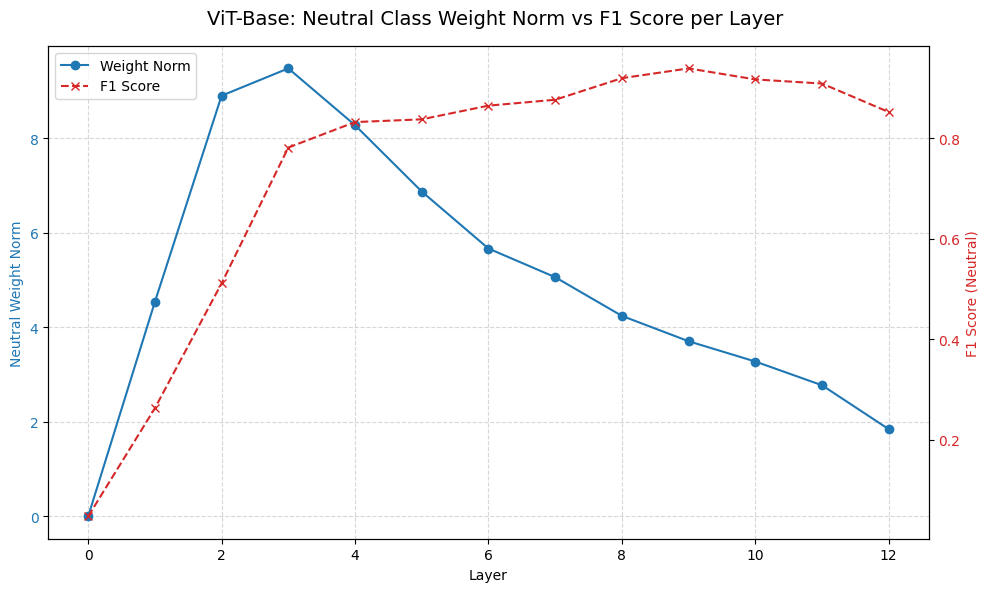

In [8]:
layer_stats = neutral_df.groupby("layer").agg({
    "weight_norm": "mean",
    "f1": "mean"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Layer')
ax1.set_ylabel('Neutral Weight Norm', color=color)
ax1.plot(layer_stats['layer'], layer_stats['weight_norm'], marker='o', color=color, label='Weight Norm')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('F1 Score (Neutral)', color=color)
ax2.plot(layer_stats['layer'], layer_stats['f1'], marker='x', linestyle='--', color=color, label='F1 Score')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('ViT-Base: Neutral Class Weight Norm vs F1 Score per Layer', fontsize=14)
fig.tight_layout()

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

In [9]:
print("Layer | Weight Norm | F1")
for _, row in layer_stats.iterrows():
    print(f"{int(row.layer):>5} | {row.weight_norm:>11.4f} | {row.f1:>4.3f}")


Layer | Weight Norm | F1
    0 |      0.0000 | 0.048
    1 |      4.5360 | 0.263
    2 |      8.8963 | 0.511
    3 |      9.4736 | 0.781
    4 |      8.2727 | 0.832
    5 |      6.8699 | 0.838
    6 |      5.6637 | 0.865
    7 |      5.0582 | 0.877
    8 |      4.2396 | 0.919
    9 |      3.7032 | 0.939
   10 |      3.2741 | 0.917
   11 |      2.7725 | 0.909
   12 |      1.8433 | 0.852


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

layer_importance = []

for layer in range(13):
    pred_df = pd.read_csv(f"./data/analysis/vitbase_cls_seed42/preds_dir/layer_{layer}_predictions.csv")
    pred_df["representation"] = pred_df["representation"].apply(ast.literal_eval)

    reps = np.stack(pred_df["representation"].values)

    neutral_mask = pred_df["predicted_label"] == 0
    if neutral_mask.sum() == 0:
        continue

    neutral_mean = reps[neutral_mask].mean(axis=0)

    neuron_scores = np.abs(neutral_mean)

    top10 = np.argsort(neuron_scores)[::-1][:10]

    layer_importance.append({
        "layer": layer,
        "weight": neuron_scores[top10].mean(),  
        "f1": base_linear_probing_res.loc[
            base_linear_probing_res.layer == layer, "f1"
        ].mean()
    })

    print(f"{layer:2d} | {neuron_scores[top10].mean():.4f} | {layer_importance[-1]['f1']:.3f}")

layer_stats = pd.DataFrame(layer_importance)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.set_xlabel("Layer")
ax1.set_ylabel("Top-Neuron Neutral Influence")
ax1.plot(layer_stats.layer, layer_stats.weight, marker="o", label="Neutral Influence")
ax1.grid(True, linestyle="--", alpha=0.4)

ax2 = ax1.twinx()
ax2.set_ylabel("Neutral F1 Score")
ax2.plot(layer_stats.layer, layer_stats.f1, marker="x", linestyle="--", label="F1 Neutral")

ax1.legend(loc="upper left")
plt.title("Layer Influence on Neutral Classification")
plt.show()


KeyError: 'representation'